In [1]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import random
from torch.distributions import Categorical

import matplotlib.pyplot as plt

In [2]:
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"State dim: {state_dim}")
print(f"Action dim: {action_dim}")
print(f"Device: {device}")

State dim: 4
Action dim: 2
Device: cuda


In [3]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        """
        state_dim: input dimension (4 for CartPole)
        action_dim: number of discrete actions (2 for CartPole)
        hidden_dim: hidden layer size
        """
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        logits = self.fc3(x)
        return torch.softmax(logits, dim=-1)


class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [4]:
def select_action(policy, state):
    """
    state -> calculate action prob. -> action sampling

    Returns:
        selected action
        log_prob: log pi(a|s)
    """
    state = torch.FloatTensor(state).unsqueeze(0).to(device)
    probs = policy(state)

    dist = Categorical(probs)
    action = dist.sample()
    log_prob = dist.log_prob(action)

    return action.item(), log_prob

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def moving_average(data, window=100):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

In [6]:
def evaluate_policy(env_name, policy, num_episodes=20, greedy=True, seed=42):
    env = gym.make(env_name)
    total_rewards = []

    for ep in range(num_episodes):
        torch.manual_seed(seed + ep)
        state, _ = env.reset(seed=seed + ep)
        ep_reward = 0
        done = False
        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                probs = policy(state_t)
            if greedy:
                action = torch.argmax(probs, dim=-1).item()
            else:
                action = Categorical(probs).sample().item()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
        total_rewards.append(ep_reward)

    env.close()
    print(f"Mean: {np.mean(total_rewards):.1f}, Std: {np.std(total_rewards):.1f}")
    return total_rewards

In [7]:
def update_actor_critic(policy_optimizer, value_optimizer, value_net,
                        state, log_prob, reward, next_state, done, gamma=0.99):
    """
    Single-step Actor-Critic update (TD, not MC)

    state, next_state: current and next state (numpy arrays)
    log_prob: log pi(a_t|s_t) from select_action
    reward: r_t
    done: whether episode terminated after this step

    TD target = r_t + gamma * V(s_{t+1}) * (1 - done)
    Advantage = TD target - V(s_{t})
        - Advantage is used for the policy loss
        - TD target is used as the regression target for the value loss
    """
    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
    next_state_t = torch.FloatTensor(next_state).unsqueeze(0).to(device)

    value = value_net(state_t).squeeze(-1)
    next_value = value_net(next_state_t).squeeze(-1)

    td_target = reward + gamma * next_value * (1 - int(done))
    advantage = td_target - value

    policy_loss = -log_prob * advantage.detach()
    policy_optimizer.zero_grad()
    policy_loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(
        policy_optimizer.param_groups[0]['params'], max_norm=float('inf')
    )
    policy_optimizer.step()

    value_loss = nn.functional.mse_loss(value, td_target.detach())
    value_optimizer.zero_grad()
    value_loss.backward()
    value_optimizer.step()

    return policy_loss.item(), value_loss.item(), grad_norm.item()


In [13]:
def train(env, policy, value_net, policy_optimizer, value_optimizer,
          num_episodes=1000, gamma=0.99, print_every=100, early_stopping=True):
    episode_rewards = []
    grad_norms = []
    action0_probs = []
    value_means = []

    ref_state, _ = env.reset(seed=9999)

    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        ep_reward = 0
        ep_grad_norms = []
        ep_values = []

        while not done:
            action, log_prob = select_action(policy, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            p_loss, v_loss, grad_norm = update_actor_critic(
                policy_optimizer, value_optimizer, value_net,
                state, log_prob, reward, next_state, done, gamma
            )
            ep_grad_norms.append(grad_norm)

            state = next_state
            ep_reward += reward
        
        episode_rewards.append(ep_reward)
        grad_norms.append(np.mean(ep_grad_norms))

        with torch.no_grad():
            ref_probs = policy(torch.FloatTensor(ref_state).unsqueeze(0).to(device))
            ref_value = value_net(torch.FloatTensor(ref_state).unsqueeze(0).to(device)).item()
        action0_probs.append(ref_probs[0, 0].item())
        value_means.append(ref_value)

        if (episode + 1) % print_every == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f"Episode {episode+1}/{num_episodes} | "
                  f"Reward: {ep_reward:.0f} | "
                  f"Avg(last 100): {avg_reward:.1f} | "
                  f"P_Loss: {p_loss:.4f} | V_Loss: {v_loss:.4f}")

        if early_stopping and len(episode_rewards) >= 100 and np.mean(episode_rewards[-100:]) >= 195:
            print(f"\nSolved at episode {episode+1}! "
                  f"Avg reward: {np.mean(episode_rewards[-100:]):.1f}")
            break

    return episode_rewards, grad_norms, action0_probs, value_means

In [32]:
set_seed(24)
env.reset(seed=24)

policy = PolicyNetwork(state_dim, action_dim).to(device)
value_net = ValueNetwork(state_dim).to(device)

policy_optimizer = optim.Adam(policy.parameters(), lr=1e-3)
value_optimizer = optim.Adam(value_net.parameters(), lr=1e-3)

rewards_ac_es, grads_ac_es, action0_probs_ac_es, value_means_ac_es = train(
    env, policy, value_net, policy_optimizer, value_optimizer,
    num_episodes=1000, early_stopping=True, gamma=0.99
)

Episode 100/1000 | Reward: 9 | Avg(last 100): 10.0 | P_Loss: -0.0000 | V_Loss: 0.3737
Episode 200/1000 | Reward: 63 | Avg(last 100): 36.8 | P_Loss: -0.0170 | V_Loss: 1894.8705
Episode 300/1000 | Reward: 408 | Avg(last 100): 132.4 | P_Loss: -0.8201 | V_Loss: 12897.7305
Episode 400/1000 | Reward: 126 | Avg(last 100): 118.1 | P_Loss: -0.0000 | V_Loss: 10.0310
Episode 500/1000 | Reward: 9 | Avg(last 100): 34.0 | P_Loss: -0.0001 | V_Loss: 6.5169
Episode 600/1000 | Reward: 10 | Avg(last 100): 9.8 | P_Loss: -0.0000 | V_Loss: 6.8352
Episode 700/1000 | Reward: 9 | Avg(last 100): 9.3 | P_Loss: -0.0000 | V_Loss: 1.0901
Episode 800/1000 | Reward: 9 | Avg(last 100): 9.3 | P_Loss: -0.0000 | V_Loss: 0.0944
Episode 900/1000 | Reward: 10 | Avg(last 100): 9.3 | P_Loss: -0.0000 | V_Loss: 0.1069
Episode 1000/1000 | Reward: 10 | Avg(last 100): 9.4 | P_Loss: -0.0000 | V_Loss: 0.0081


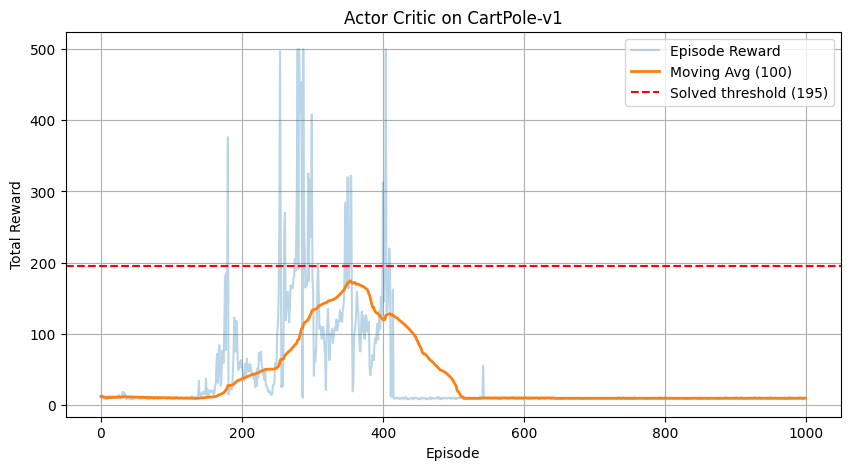

In [33]:
def moving_average(data, window=100):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

plt.figure(figsize=(10, 5))
plt.plot(rewards_ac_es, alpha=0.3, label='Episode Reward')
plt.plot(moving_average(rewards_ac_es), label='Moving Avg (100)', linewidth=2)
plt.axhline(y=195, color='r', linestyle='--', label='Solved threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Actor Critic on CartPole-v1')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
set_seed(42)
env.reset(seed=42)

policy_1000    = PolicyNetwork(state_dim, action_dim).to(device)
value_net_1000 = ValueNetwork(state_dim).to(device)

policy_optimizer_1000 = optim.Adam(policy_1000.parameters(), lr=1e-3)
value_optimizer_1000  = optim.Adam(value_net_1000.parameters(), lr=1e-3)

print("=== Actor-Critic (1000 episodes, no early stopping) ===")
rewards_ac_1000, grads_ac_1000, action0_probs_ac_1000, value_means_ac_1000 = train(
    env, policy_1000, value_net_1000, policy_optimizer_1000, value_optimizer_1000,
    num_episodes=1000, print_every=100, early_stopping=False, gamma=0.99
)

=== Actor-Critic (1000 episodes, no early stopping) ===
Episode 100/1000 | Reward: 66 | Avg(last 100): 18.9 | P_Loss: -7.1609 | V_Loss: 660.3846
Episode 200/1000 | Reward: 39 | Avg(last 100): 85.1 | P_Loss: 3.6328 | V_Loss: 39.2645
Episode 300/1000 | Reward: 10 | Avg(last 100): 57.8 | P_Loss: -0.0000 | V_Loss: 1.5216
Episode 400/1000 | Reward: 9 | Avg(last 100): 9.5 | P_Loss: -0.0000 | V_Loss: 29.3167
Episode 500/1000 | Reward: 9 | Avg(last 100): 9.2 | P_Loss: -0.0000 | V_Loss: 3.0035
Episode 600/1000 | Reward: 10 | Avg(last 100): 9.3 | P_Loss: -0.0000 | V_Loss: 0.0852
Episode 700/1000 | Reward: 9 | Avg(last 100): 9.3 | P_Loss: -0.0000 | V_Loss: 0.1642
Episode 800/1000 | Reward: 9 | Avg(last 100): 9.3 | P_Loss: -0.0000 | V_Loss: 0.0036
Episode 900/1000 | Reward: 10 | Avg(last 100): 9.3 | P_Loss: -0.0000 | V_Loss: 0.2364
Episode 1000/1000 | Reward: 10 | Avg(last 100): 9.4 | P_Loss: -0.0000 | V_Loss: 0.0006


In [35]:
rewards_v1000 = np.load('../../04_Policy_Gradient/code/rewards_vanilla_1000.npy')
rewards_b1000 = np.load('../../04_Policy_Gradient/code/rewards_baseline_1000.npy')
grads_v1000 = np.load('../../04_Policy_Gradient/code/grads_vanilla_1000.npy')
grads_b1000 = np.load('../../04_Policy_Gradient/code/grads_baseline_1000.npy')
action0_probs_v1000  = np.load('../../04_Policy_Gradient/code/action0_probs_vanilla_1000.npy')
action0_probs_b1000 = np.load('../../04_Policy_Gradient/code/action0_probs_baseline_1000.npy')
value_means_b1000 = np.load('../../04_Policy_Gradient/code/value_means_baseline_1000.npy')

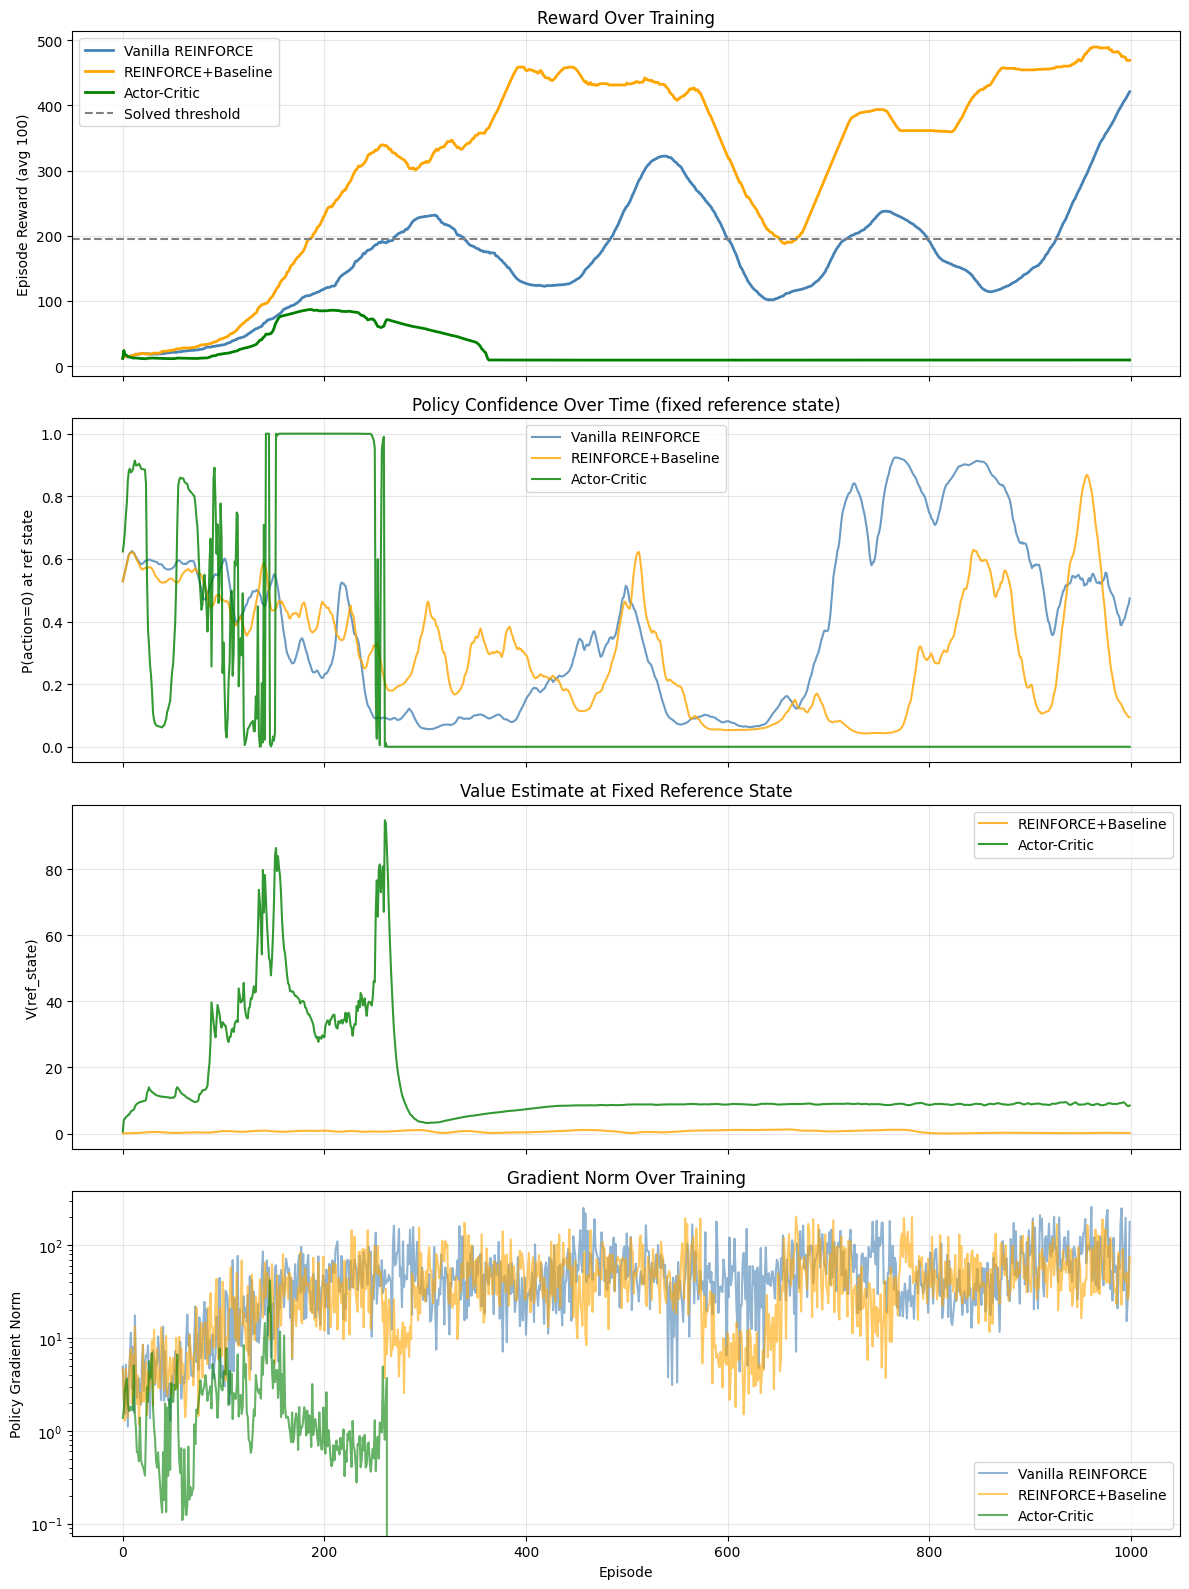

In [36]:
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# 1. Reward
axes[0].plot(moving_average(rewards_v1000), label='Vanilla REINFORCE', color='steelblue', linewidth=2)
axes[0].plot(moving_average(rewards_b1000), label='REINFORCE+Baseline', color='orange', linewidth=2)
axes[0].plot(moving_average(rewards_ac_1000), label='Actor-Critic', color='green', linewidth=2)
axes[0].axhline(y=195, color='gray', linestyle='--', label='Solved threshold')
axes[0].set_ylabel('Episode Reward (avg 100)')
axes[0].set_title('Reward Over Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Policy confidence at fixed reference state
axes[1].plot(action0_probs_v1000, label='Vanilla REINFORCE', color='steelblue', alpha=0.8)
axes[1].plot(action0_probs_b1000, label='REINFORCE+Baseline', color='orange', alpha=0.8)
axes[1].plot(action0_probs_ac_1000, label='Actor-Critic', color='green', alpha=0.8)
axes[1].set_ylabel('P(action=0) at ref state')
axes[1].set_title('Policy Confidence Over Time (fixed reference state)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. V(ref_state)
axes[2].plot(value_means_b1000, label='REINFORCE+Baseline', color='orange', alpha=0.8)
axes[2].plot(value_means_ac_1000, label='Actor-Critic', color='green', alpha=0.8)
axes[2].set_ylabel('V(ref_state)')
axes[2].set_title('Value Estimate at Fixed Reference State')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Gradient norm
axes[3].plot(grads_v1000, label='Vanilla REINFORCE', color='steelblue', alpha=0.6)
axes[3].plot(grads_b1000, label='REINFORCE+Baseline', color='orange', alpha=0.6)
axes[3].plot(grads_ac_1000, label='Actor-Critic', color='green', alpha=0.6)
axes[3].set_ylabel('Policy Gradient Norm')
axes[3].set_xlabel('Episode')
axes[3].set_title('Gradient Norm Over Training')
axes[3].legend()
axes[3].set_yscale('log')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()